# Model 1: Fully connected Neural Network for predicting match outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import GradientBoostingClassifier
from torch.utils.data import DataLoader
from itertools import product
from copy import deepcopy

In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score, precision_score, recall_score, classification_report
from matplotlib.ticker import MaxNLocator, PercentFormatter
from pathlib import Path

In [3]:
# Use Metal Performance Shaders if available (GPU acceleration).
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device to be used for training: {device}")

Device to be used for training: mps


### 1. Read the preprocessed data

This notebook reads the preprocessed data directly. The full preprocessing pipeline, consisting of cleaning and feature engineering, is available in `preprocessing.ipynb`.

In [4]:
# Read in the cleaned data.
numeric_dtypes = {
    "Best of": "Int64",
    "Rank_1": "Int64",
    "Rank_2": "Int64",
    "Pts_1": "Int64",
    "Pts_2": "Int64",
    "Odd_1": "Float64",
    "Odd_2": "Float64",
    "Margin": "Float64",
    "Prob_1": "Float64",
    "Prob_2": "Float64",
    "WinRate180_1": "Float64",
    "WinRateLast5_365_1": "Float64",
    "WinRate180_2": "Float64",
}

wta = pd.read_csv(
    "../data/clean_wta.csv",
    dtype=numeric_dtypes,
    parse_dates=["Date"],
    na_values=["", "NA", "N/A", "null", "None", "-"],
    keep_default_na=True,
)


### 2. Create Training, Validation, and Test Sets

As the data form a time series, careful consideration is required when creating the training, validation, and test sets.

Typical strategies, such as random sampling and k-fold cross-validation, may be unsuitable because a model cannot access future data points during training in real-world applications.

For simplicity, I sort the dataset chronologically, using the first 80% of records for training, the subsequent 10% for hyperparameter tuning, and the remaining 10% to assess model performance.

In [5]:
# Create Chronological train(80%)/validation(10%)/test(10%) splits

# Choose date boundaries near 80% and 90% of the wta rows.
validation_start = wta["Date"].iloc[int(len(wta) * 0.8)]
test_start = wta["Date"].iloc[int(len(wta) * 0.9)]

train = wta.loc[wta["Date"] < validation_start].copy() # Train split

validation = wta.loc[(wta["Date"] >= validation_start) & (wta["Date"] < test_start)].copy() # Validation split

test = wta.loc[wta["Date"] >= test_start].copy() # Test split

In [6]:
# Verify that all rows from the dataset are assigned to a set and the date ranges do not overlap between them.

assert len(train) + len(validation) + len(test) == len(wta)

assert train["Date"].max() < validation["Date"].min()

assert validation["Date"].max() < test["Date"].min()

split_summary = pd.DataFrame([
    {
        "Split": name,
        "Rows": len(part),
        "Percent": round(100 * len(part) / len(wta), 2),
        "Start": part["Date"].min(),
        "End": part["Date"].max(),
    }
    for name, part in [
        ("Train", train), ("Validation", validation), ("Test", test)
    ]
])

display(split_summary)

,Split,Rows,Percent,Start,End
0,Train,35667,79.98,2006-12-31,2022-08-16
1,Validation,4464,10.01,2022-08-17,2024-07-16
2,Test,4464,10.01,2024-07-17,2026-06-06


### Create the targets $\hat{y}$.

In [7]:
# Create inputs and targets for the outcome prediction task.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import TensorDataset

basic_features = ["Court", "Surface", "Rank_1", "Rank_2"]
basic_features_enhanced = basic_features + ["Margin"]

# Switch to basic_features_enhanced to include bookmaker overround (Margins).
features = basic_features
categorical_features = ["Court", "Surface"]
numeric_features = [name for name in features if name not in categorical_features]

# 1. Impute and standardize numerical inputs; one-hot encode categories.
# Fit every preprocessing step on training data only.
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(
        handle_unknown="ignore", sparse_output=False
    ), categorical_features),
])

X_train_array = preprocessor.fit_transform(train[features])
X_validation_array = preprocessor.transform(validation[features])
X_test_array = preprocessor.transform(test[features])
feature_names = preprocessor.get_feature_names_out()

# 2. Target: 1 = Player 1 wins, 0 = Player 2 wins.
# CrossEntropyLoss expects a one-dimensional tensor of integer class labels.
def make_targets(matches):
    valid_winners = (
        matches["Winner"].eq(matches["Player_1"])
        | matches["Winner"].eq(matches["Player_2"])
    )
    if not valid_winners.fillna(False).all():
        raise ValueError("Each Winner must match Player_1 or Player_2.")

    labels = matches["Winner"].eq(matches["Player_1"]).astype("int64")
    return torch.tensor(labels.to_numpy(), dtype=torch.long, device=device)

# 3. Convert to tensors on the selected CPU/GPU, preserving split row order.
X_train = torch.tensor(X_train_array, dtype=torch.float32, device=device)
X_validation = torch.tensor(X_validation_array, dtype=torch.float32, device=device)
X_test = torch.tensor(X_test_array, dtype=torch.float32, device=device)

y_train = make_targets(train)
y_validation = make_targets(validation)
y_test = make_targets(test)

train_data = TensorDataset(X_train, y_train)
validation_data = TensorDataset(X_validation, y_validation)
test_data = TensorDataset(X_test, y_test)

input_size = X_train.shape[1]

for name, inputs, targets in [
    ("Train", X_train, y_train),
    ("Validation", X_validation, y_validation),
    ("Test", X_test, y_test),
]:
    assert torch.isfinite(inputs).all(), f"{name} inputs contain NaN or infinity."
    assert inputs.shape[0] == targets.shape[0]
    print(f"{name}: inputs {tuple(inputs.shape)}, targets {tuple(targets.shape)}")

print("Encoded features:", list(feature_names))


Train: inputs (35667, 9), targets (35667,)
Validation: inputs (4464, 9), targets (4464,)
Test: inputs (4464, 9), targets (4464,)
Encoded features: ['numeric__Rank_1', 'numeric__Rank_2', 'categorical__Court_Indoor', 'categorical__Court_Outdoor', 'categorical__Surface_Carpet', 'categorical__Surface_Clay', 'categorical__Surface_Grass', 'categorical__Surface_Greenset', 'categorical__Surface_Hard']


This is the shape the input tensor for the model:

In [8]:
X_train.shape[1]

9

### 3. Establish Two Baselines for Model Performance Comparisons

I establish two baselines against which to compare each trained model:

1. **Rank-based:** The higher-ranked player is predicted to win.
2. **Bookmaker's pick:** The player assigned the higher *normalized probability* by the bookmaker is predicted to win.

These will help set reasonable expectations for the model performance and provide insight into whether we have learned anything from the data.

In [9]:
# Establish Two Baselines for Metric Comparisons. Ties are resolved simply by choosing Player 1.

# 1. Picking the higher ranked player.
# A smaller rank number means a higher-ranked player.

rank_preds = wta["Player_1"].where(
    wta["Rank_1"] <= wta["Rank_2"],
    wta["Player_2"],
)

# 2. the bookmaker's odds against actual match victory.

bookmaker_prob_preds = wta["Player_1"].where(
    wta["Prob_1"] >= wta["Prob_2"],
    wta["Player_2"],
)

### 4. Define the model architecture (Fully Connected Neural Network with two hidden layers), the training loop and the loss function.

Though I have used the ReLU activation function due to its popularity, sigmoid and tanh are also viable alternatives.

In [10]:
# Model 1: Fully Connected Neural Network with 2 hidden layers with the basic features (x).

class FullyConnected2lNeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_size_l2, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size, bias=True)  # First layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size_l2, bias=True) # Second layer
        self.fc3 = nn.Linear(hidden_size_l2, num_classes, bias=False) # Output layer

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

In [11]:
# Train using chronological splits; use validation loss to select the epoch.

def evaluate_model(model, data_loader, criterion):
    """Evaluate the model after each epoch without gradient updates.
    Return sample-weighted mean loss and classification accuracy."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    model_device = next(model.parameters()).device

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(model_device)
            targets = targets.to(model_device)

            logits = model(inputs)
            loss = criterion(logits, targets)

            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += targets.size(0)

    return total_loss / total_samples, total_correct / total_samples


def training_loop(model,
                  train_data,
                  validation_data,
                  optimizer,
                  criterion,
                  num_epochs=10,
                  batch_size=64):
    
    if num_epochs < 1 or len(train_data) == 0 or len(validation_data) == 0:
        raise ValueError("Use at least one epoch and non-empty training/validation sets.")

    # Preserve chronological order of the training data.
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)

    validation_loader = DataLoader(validation_data,batch_size=batch_size, shuffle=False)
    
    model_device = next(model.parameters()).device
    history = []
    best_validation_loss = float("inf")
    best_state = None
    best_epoch = None

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(model_device)
            targets = targets.to(model_device)

            optimizer.zero_grad()
            # feed forward
            logits = model(inputs)
            
            # CrossEntropyLoss takes logits, not softmax.
            loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise ValueError("Training loss became non-finite.")

            # backprop
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += targets.size(0)

        # Summarize the loss and accuracy for the epoch.
        train_loss = total_loss / total_samples
        train_accuracy = total_correct / total_samples
        validation_loss, validation_accuracy = evaluate_model(
            model, validation_loader, criterion)
        if not torch.isfinite(torch.tensor(validation_loss)):
            raise ValueError("Validation loss became non-finite.")

        # Save to history.
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy})

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            # Clone weights for best epoch so later updates cannot overwrite the saved best weights.
            best_epoch = epoch
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss {train_loss:.4f}, accuracy {train_accuracy:.2%} | "
            f"validation loss {validation_loss:.4f}, "
            f"accuracy {validation_accuracy:.2%}"
        )

    # Restore the best epoch by loss for inference.
    model.load_state_dict(best_state)
    model.eval()
    print(f"Restored epoch {best_epoch} (validation loss {best_validation_loss:.4f}).")
    return pd.DataFrame(history)


At this stage, I'd like to test the code pipeline before implementing further changes. I define the set of hyperparameters and pick values for them manually. Later on, we will run a grid search to find the best set of hyperparameters.

In [12]:
# Define hyperparameters for model 1
input_size = X_train.shape[1] # Number of encoded input features.
hidden_size = 64   # Width of the first hidden layer.
hidden_size_l2 = 8 # Width of the second hidden layer.
num_classes = 2    # Number of output classes (binar classification task).
learning_rate = 0.001
num_epochs = 30
batch_size = 100  # Define batch size

In [13]:
# Loss function and optimizer setup.

torch.manual_seed(42)  # Reproducible initialization on the same backend.
model1 = FullyConnected2lNeuralNet(input_size, hidden_size, hidden_size_l2, num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model1.parameters(), lr=learning_rate)

Epoch 01/30 | train loss 0.6385, accuracy 64.51% | validation loss 0.6425, accuracy 62.88%
Epoch 02/30 | train loss 0.6232, accuracy 65.29% | validation loss 0.6398, accuracy 63.08%
Epoch 03/30 | train loss 0.6217, accuracy 65.38% | validation loss 0.6385, accuracy 63.13%
Epoch 04/30 | train loss 0.6210, accuracy 65.40% | validation loss 0.6382, accuracy 63.31%
Epoch 05/30 | train loss 0.6206, accuracy 65.45% | validation loss 0.6383, accuracy 63.28%
Epoch 06/30 | train loss 0.6203, accuracy 65.45% | validation loss 0.6384, accuracy 63.22%
Epoch 07/30 | train loss 0.6200, accuracy 65.49% | validation loss 0.6381, accuracy 63.24%
Epoch 08/30 | train loss 0.6199, accuracy 65.49% | validation loss 0.6380, accuracy 63.35%
Epoch 09/30 | train loss 0.6198, accuracy 65.46% | validation loss 0.6380, accuracy 63.19%
Epoch 10/30 | train loss 0.6197, accuracy 65.46% | validation loss 0.6375, accuracy 63.28%
Epoch 11/30 | train loss 0.6196, accuracy 65.48% | validation loss 0.6374, accuracy 63.40%

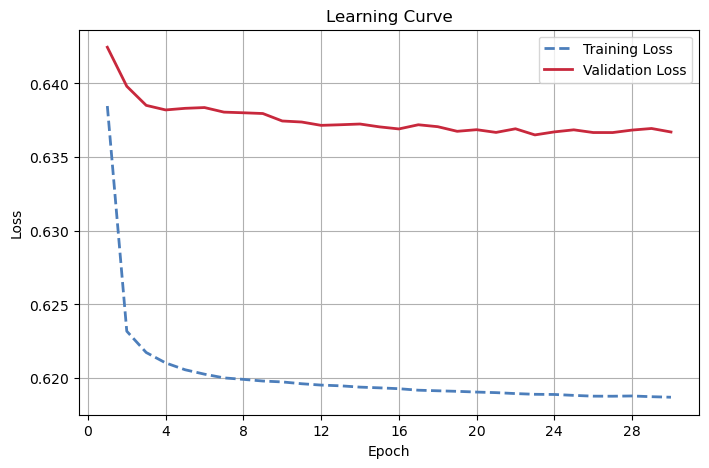

,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy
0,1,0.638468,0.645078,0.642460,0.628808
1,2,0.623186,0.652872,0.639810,0.630824
2,3,0.621740,0.653798,0.638514,0.631272
3,4,0.621032,0.653966,0.638204,0.633065
4,5,0.620568,0.654471,0.638313,0.632841
5,6,0.620268,0.654527,0.638365,0.632168
6,7,0.620017,0.654891,0.638055,0.632392
7,8,0.619916,0.654863,0.638011,0.633513
8,9,0.619803,0.654555,0.637960,0.631944
9,10,0.619742,0.654611,0.637453,0.632841


In [14]:
# Train model 1 and record learning curves. Re-run the setup cell for a fresh model.
history_model1 = training_loop(
    model=model1,
    train_data=train_data,
    validation_data=validation_data,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs,
    batch_size=batch_size,
)

# Plot the learning curve: training and validation loss for each epoch.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_model1["epoch"], history_model1["train_loss"],
        linestyle="--", linewidth=2, color="#4C7EBB", label="Training Loss")
ax.plot(history_model1["epoch"], history_model1["validation_loss"],
        linewidth=2, color="#C8283C", label="Validation Loss")
ax.set_title("Learning Curve")
ax.set_xlabel("Epoch")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Whole epochs only.
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend()
plt.show()

history_model1


In [15]:
# Now use model 1 on the test set to predict the outcome and calculate accuracy.
# Run after training, which restores the best validation-loss weights.
model1.eval()

with torch.no_grad():
    test_logits = model1(X_test)
    test_probabilities = torch.softmax(test_logits, dim=1)
    model1_test_preds = test_logits.argmax(dim=1)
    model1_test_correct = (model1_test_preds == y_test).sum().item()

model1_test_accuracy = model1_test_correct / len(y_test)

# Class 1 = Player 1 wins; class 0 = Player 2 wins.
# Preserve the test DataFrame's index and row order.
test_results = test[["Date", "Player_1", "Player_2", "Winner"]].copy()
test_results["Predicted_class"] = model1_test_preds.cpu().numpy()
test_results["Model1_Prob_1"] = test_probabilities[:, 1].cpu().numpy()
test_results["Predicted_winner"] = test_results["Player_1"].where(
    test_results["Predicted_class"].eq(1), test_results["Player_2"]
)
test_results["Correct"] = test_results["Predicted_winner"].eq(test_results["Winner"])

print(f"Model 1 test accuracy (no grid search): {model1_test_accuracy:.2%} "
    f"({model1_test_correct:,}/{len(y_test):,} matches)")
# display(test_results.head())


Model 1 test accuracy (no grid search): 63.17% (2,820/4,464 matches)


### 5. Fine-tune the hyperparameters for the model with Grid Search.

This can take some time (~20 min on my Macbook M1 with MPS). We try out 18 different combinations of hyperparameters. Feel free to comment the code block out if you would like to skip this step.

In [16]:
# # Implement grid search over hyperparameters for selecting the hyperparameters that minimize validation loss.

# learning_rates = [0.001, 0.01]
# layer1_sizes = [25, 64, 100]
# layer2_sizes = [8, 32, 50]

# search_results = []
# best_model = None
# best_config = None
# best_history = None
# best_val_loss = float("inf")

# for lr, size1, size2 in product(
#     learning_rates, layer1_sizes, layer2_sizes):

#     # Start every trial from a fresh model.
#     torch.manual_seed(42)

#     candidate = FullyConnected2lNeuralNet(
#         input_size=X_train.shape[1],
#         hidden_size=size1,
#         hidden_size_l2=size2,
#         num_classes=2).to(device)

#     candidate_optimizer = torch.optim.Adam(candidate.parameters(), lr=lr)
#     candidate_criterion = nn.CrossEntropyLoss()

#     print(f"\nTrial: learning rate={lr}, layers=({size1}, {size2})")

#     history = training_loop(
#         model=candidate,
#         train_data=train_data,
#         validation_data=validation_data,
#         optimizer=candidate_optimizer,
#         criterion=candidate_criterion,
#         num_epochs=20,
#         batch_size=64,
#     )

#     # The training_loop already restores the best validation-loss weights.
#     best_epoch_row = history.loc[history["validation_loss"].idxmin()]

#     result = {
#         "learning_rate": lr,
#         "hidden_size": size1,
#         "hidden_size_l2": size2,
#         "best_epoch": int(best_epoch_row["epoch"]),
#         "validation_loss": float(best_epoch_row["validation_loss"]),
#         "validation_accuracy": float(best_epoch_row["validation_accuracy"]),
#     }
#     search_results.append(result)

#     if result["validation_loss"] < best_val_loss:
#         best_val_loss = result["validation_loss"]
#         best_config = result.copy()
#         best_model = deepcopy(candidate)
#         best_history = history.copy()

# search_results = (
#     pd.DataFrame(search_results)
#     .sort_values("validation_loss")
#     .reset_index(drop=True)
# )

# model1 = best_model
# history_model1 = best_history
# display(search_results)
# print("Selected configuration:", best_config)

In [17]:
# To disable grid search

best_model = model1

In [18]:
best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_test)
    test_probabilities = torch.softmax(test_logits, dim=1)
    bestmodel_test_preds = test_logits.argmax(dim=1)
    bestmodel_test_correct = (bestmodel_test_preds == y_test).sum().item()

bestmodel_test_accuracy = bestmodel_test_correct / len(y_test)

# Class 1 = Player 1 wins; class 0 = Player 2 wins.
# Preserve the test DataFrame's index and row order.
test_results = test[["Date", "Player_1", "Player_2", "Winner"]].copy()
test_results["Predicted_class"] = bestmodel_test_preds.cpu().numpy()
test_results["BestModel_Prob_1"] = test_probabilities[:, 1].cpu().numpy()
test_results["Predicted_winner"] = test_results["Player_1"].where(
    test_results["Predicted_class"].eq(1), test_results["Player_2"]
)
test_results["Correct"] = test_results["Predicted_winner"].eq(test_results["Winner"])

print(f"Best model test accuracy: {bestmodel_test_accuracy:.2%} "
    f"({bestmodel_test_correct:,}/{len(y_test):,} matches)")

Best model test accuracy: 63.17% (2,820/4,464 matches)


### 6. Analysis and Performance Metrics

#### Confusion Matrix

We can look at the confusion matrix to see which predictions were correct and which kinds of mistakes the model made.

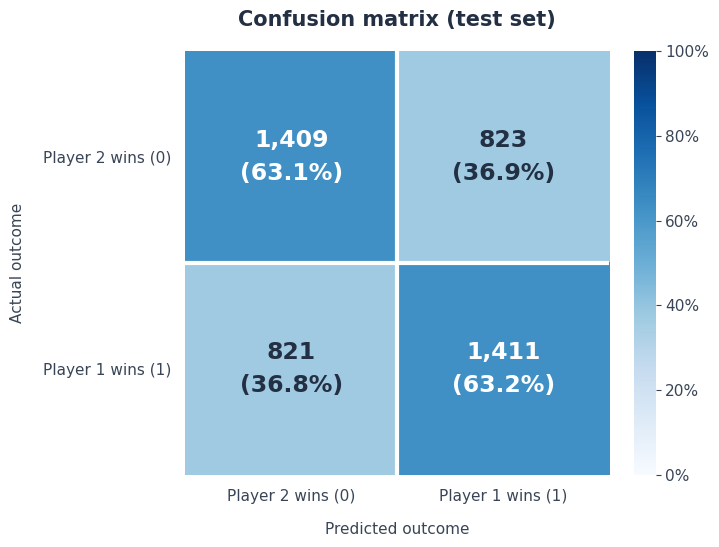

In [19]:
# Make a confusion matrix for the winner prediction task for the best model.
# Evaluate on the held-out test split; rows = actual, columns = predicted.

best_model.eval()
model_device = next(best_model.parameters()).device

with torch.no_grad():
    cm_predictions = torch.cat([
        best_model(batch.to(model_device)).argmax(dim=1).cpu()
        for batch in X_test.split(1024)
    ]).numpy()

cm_targets = y_test.detach().cpu().numpy()
# Fixed order: class 0 = Player 2 wins, class 1 = Player 1 wins.
cm_counts = confusion_matrix(cm_targets, cm_predictions, labels=[0, 1])
row_totals = cm_counts.sum(axis=1, keepdims=True)
cm_rates = np.divide(
    cm_counts, row_totals,
    out=np.zeros_like(cm_counts, dtype=float), where=row_totals != 0,
)
cm_accuracy = np.trace(cm_counts) / cm_counts.sum()
class_labels = ["Player 2 wins (0)", "Player 1 wins (1)"]

confusion_table = pd.DataFrame(
    cm_counts,
    index=pd.Index(class_labels, name="Actual outcome"),
    columns=pd.Index(class_labels, name="Predicted outcome"),
)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "text.color": "#233044",
    "axes.labelcolor": "#394556",
    "xtick.color": "#394556",
    "ytick.color": "#394556",
    "figure.facecolor": "white",
}):
    confusion_fig, ax = plt.subplots(figsize=(7, 5.6))
    heatmap = ax.imshow(cm_rates, cmap="Blues", vmin=0, vmax=1)

    for row in range(2):
        for col in range(2):
            percentage = f"{cm_rates[row, col]:.1%}" if row_totals[row, 0] else "N/A"
            ax.text(
                col, row, f"{cm_counts[row, col]:,}\n({percentage})",
                ha="center", va="center", fontsize=17, fontweight="bold",
                color="white" if cm_rates[row, col] > 0.55 else "#233044",
                linespacing=1.6,
            )

    ax.set_xticks([0, 1], class_labels)
    ax.set_yticks([0, 1], class_labels)
    ax.set_xlabel("Predicted outcome", labelpad=13)
    ax.set_ylabel("Actual outcome", labelpad=13)
    ax.tick_params(axis="both", length=0, pad=10)
    ax.set_xticks([0.5], minor=True)
    ax.set_yticks([0.5], minor=True)
    ax.grid(which="minor", color="white", linewidth=3)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    colorbar = confusion_fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.05)
    colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    colorbar.outline.set_visible(False)

    ax.set_title("Confusion matrix (test set)", fontsize=15, fontweight="bold", pad=18)
    confusion_fig.tight_layout()
    plt.show()


Recall the two baselines established in Step 3. These provide useful comparisons and insights into the performance of the best-performing model.

In [20]:
rank_accuracy = rank_preds.loc[test.index].eq(test["Winner"]).mean()
bookmaker_accuracy = bookmaker_prob_preds.loc[test.index].eq(test["Winner"]).mean()
rank_accuracy_train = rank_preds.loc[train.index].eq(train["Winner"]).mean()
bookmaker_accuracy_train = bookmaker_prob_preds.loc[train.index].eq(train["Winner"]).mean()

print(f"Rank baseline accuracy (test/train splits): {rank_accuracy:.2%}, {rank_accuracy_train:.2%}")
print(f"Bookmaker baseline accuracy (test/train splits): {bookmaker_accuracy:.2%}, {bookmaker_accuracy_train:.2%}")

Rank baseline accuracy (test/train splits): 63.13%, 65.49%
Bookmaker baseline accuracy (test/train splits): 68.62%, 69.26%


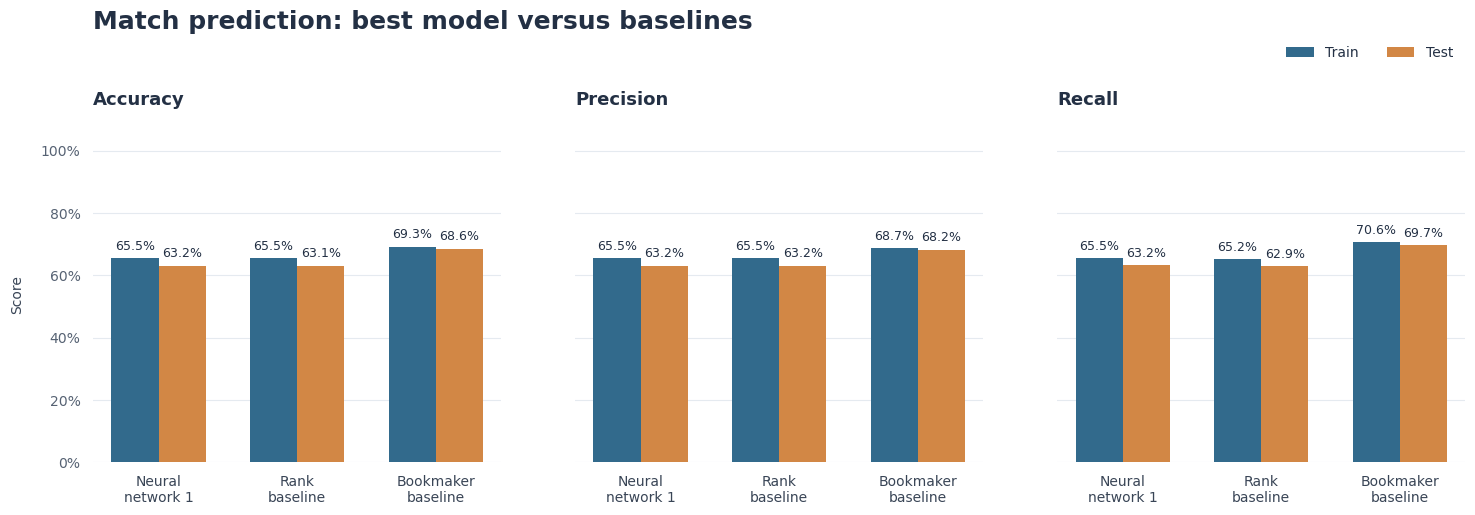

,Model,Split,Matches,Accuracy,Precision,Recall
0,Neural network 1,Train,"35,667",65.52%,65.51%,65.47%
1,Rank baseline,Train,"35,667",65.49%,65.55%,65.22%
2,Bookmaker baseline,Train,"35,667",69.26%,68.74%,70.59%
3,Neural network 1,Test,"4,464",63.17%,63.16%,63.22%
4,Rank baseline,Test,"4,464",63.13%,63.17%,62.95%
5,Bookmaker baseline,Test,"4,464",68.62%,68.23%,69.67%


In [21]:
# Compare train/test accuracy, precision and recall for the best model and baselines.
# These are grouped bar charts: each bar summarises a classification metric.

if best_model is None:
    raise ValueError("Run the hyperparameter search to select best_model first.")

best_model.eval()
model_device = next(best_model.parameters()).device
metric_rows = []

for split_name, matches, inputs, targets in [
    ("Train", train, X_train, y_train),
    ("Test", test, X_test, y_test),
]:
    actual = matches["Winner"].eq(matches["Player_1"]).astype(int).to_numpy()
    assert np.array_equal(actual, targets.detach().cpu().numpy())

    # Recompute predictions using the selected weights, including on train.
    # Epoch training metrics use changing weights and are not comparable here.
    with torch.no_grad():
        nn_predictions = torch.cat([
            best_model(batch.to(model_device)).argmax(dim=1).cpu()
            for batch in inputs.split(1024)
        ]).numpy()

    if matches[["Rank_1", "Rank_2", "Prob_1", "Prob_2"]].isna().any().any():
        raise ValueError("Baseline inputs must be present for every evaluated match.")

    predictions = {
        "Neural network 1": nn_predictions,
        # Match the existing baselines: choose Player 1 when tied.
        "Rank baseline": matches["Rank_1"].le(matches["Rank_2"]).astype(int).to_numpy(),
        "Bookmaker baseline": matches["Prob_1"].ge(matches["Prob_2"]).astype(int).to_numpy(),
    }

    for model_name, predicted in predictions.items():
        metric_rows.append({
            "Model": model_name,
            "Split": split_name,
            "Matches": len(actual),
            "Accuracy": accuracy_score(actual, predicted),
            "Precision": precision_score(actual, predicted, pos_label=1, zero_division=0),
            "Recall": recall_score(actual, predicted, pos_label=1, zero_division=0),
        })

comparison_metrics = pd.DataFrame(metric_rows)
model_order = ["Neural network 1", "Rank baseline", "Bookmaker baseline"]
model_labels = ["Neural\nnetwork 1", "Rank\nbaseline", "Bookmaker\nbaseline"]
split_colors = {"Train": "#326A8C", "Test": "#D28745"}

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#394556",
    "text.color": "#233044",
    "xtick.color": "#394556",
    "ytick.color": "#566273",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}):
    comparison_fig, axes = plt.subplots(1, 3, figsize=(15, 5.8), sharey=True)
    x = np.arange(len(model_order))
    width = 0.34

    for ax, metric in zip(axes, ["Accuracy", "Precision", "Recall"]):
        for split_name, offset in [("Train", -width / 2), ("Test", width / 2)]:
            values = (
                comparison_metrics.loc[comparison_metrics["Split"].eq(split_name)]
                .set_index("Model")
                .loc[model_order, metric]
                .to_numpy() * 100
            )
            bars = ax.bar(
                x + offset, values, width=width,
                color=split_colors[split_name], label=split_name, zorder=3,
            )
            ax.bar_label(
                bars, labels=[f"{value:.1f}%" for value in values],
                padding=4, fontsize=9, color="#233044",
            )

        ax.set_title(metric, loc="left", pad=15)
        ax.set_xticks(x, model_labels)
        ax.set_ylim(0, 108)  # Space above 100% for value labels.
        ax.set_yticks(np.arange(0, 101, 20))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.grid(axis="y", color="#E5EAF0", linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", length=0, pad=9)
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[0].set_ylabel("Score", labelpad=12)
    comparison_fig.suptitle(
        "Match prediction: best model versus baselines",
        x=0.07, y=0.97, ha="left", fontsize=18, fontweight="bold",
    )
    handles, labels = axes[0].get_legend_handles_labels()
    comparison_fig.legend(
        handles, labels, loc="upper right", bbox_to_anchor=(0.985, 0.93),
        ncol=2, frameon=False,
    )

    comparison_fig.subplots_adjust(
        left=0.07, right=0.985, top=0.77, bottom=0.19, wspace=0.18
    )
    plt.show()

# Exact metric values remain available for reporting.
display(comparison_metrics.style.format({
    "Matches": "{:,}",
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
}))

#### AUC-ROC 
The Area Under the Receiver Operating Characteristic Curve (AUC-ROC) evaluates how well a model can distinguish between the two classes of a binary classification task.

In [22]:
# Code for AUC-ROC.
# AUC-ROC needs a score for how likely Player 1 is to win, not the predicted class.
from sklearn.metrics import roc_auc_score

summary_scores = {
    "fcnn_basic": test_probabilities[:, 1].cpu().numpy(),
    # Higher when Player 1 is ranked better than Player 2.
    "rank_baseline": np.log(test["Rank_2"] / test["Rank_1"]).to_numpy(dtype=float),
    "bookmaker_baseline": test["Prob_1"].to_numpy(dtype=float),
}
auc_scores = {name: roc_auc_score(cm_targets, scores) for name, scores in summary_scores.items()}
pd.Series(auc_scores, name="AUC-ROC")

fcnn_basic            0.695839
rank_baseline         0.699227
bookmaker_baseline    0.758716
Name: AUC-ROC, dtype: float64

I will save the performance metrics to output/summary.csv for later histograms where I compare the performance of this first model with later iterations.

In [23]:
# Save test-set metrics for the best model and both baselines to output/summary.csv.

summary_predictions = {
    "fcnn_basic": cm_predictions,
    # Match the existing baselines: choose Player 1 when tied.
    "rank_baseline": test["Rank_1"].le(test["Rank_2"]).astype(int).to_numpy(),
    "bookmaker_baseline": test["Prob_1"].ge(test["Prob_2"]).astype(int).to_numpy(),
}

summary = pd.DataFrame([
    {
        "model": model_name,
        "precision": precision_score(cm_targets, predicted, zero_division=0),
        "recall": recall_score(cm_targets, predicted, zero_division=0),
        "f1": f1_score(cm_targets, predicted, zero_division=0),
        "accuracy": accuracy_score(cm_targets, predicted),
        "auc_roc": auc_scores[model_name],
    }
    for model_name, predicted in summary_predictions.items()
])

project_root = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
summary_path = project_root / "output" / "summary.csv"
summary_path.parent.mkdir(exist_ok=True)
# Keep other models' rows; replace a model's row only when it is saved again.
if summary_path.exists():
    saved = pd.read_csv(summary_path)
    summary = pd.concat([saved[~saved["model"].isin(summary["model"])], summary])
summary.to_csv(summary_path, index=False, float_format="%.4f")

### 7. Export the Selected Model for Inference Without Retraining

In [24]:
import joblib

In [25]:
# project_root = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
# export_path = project_root / "models" / "FCNN_2layer"
# export_path.mkdir(parents=True, exist_ok=True)

# model_artifact = {
#     "model_type": type(best_model).__name__,
#     "model_state_dict": {
#         name: parameter.detach().cpu()
#         for name, parameter in best_model.state_dict().items()
#     },
#     "input_size": best_model.fc1.in_features,
#     "hidden_size": best_model.fc1.out_features,
#     "hidden_size_l2": best_model.fc2.out_features,
#     "num_classes": best_model.fc3.out_features,
# }
# torch.save(model_artifact, export_path / "model.pt")

# preprocessing_artifact = {
#     "preprocessor": preprocessor,
#     "features": features,
#     "feature_names": list(feature_names),
# }
# joblib.dump(preprocessing_artifact, export_path / "preprocessing.joblib")

# print("Saved selected model and preprocessing to:", export_path)